In [1]:
from tensor import Tensor
import numpy as np
from utils.graph_visualizer import draw_dot

In [2]:
a = Tensor(np.array([[1,2,3], [4,5,6]]), requires_grad=True)
b = Tensor(5, requires_grad=True)
d = Tensor(np.array([5,5,5]), requires_grad=True)
c = (a + b) * d

In [3]:
e = (c**2).sum()

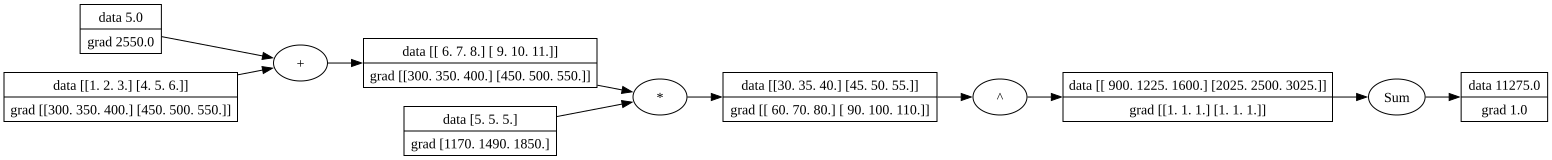

In [6]:
draw_dot(e)

In [5]:
e.zero_grad()
e.backward()

In [5]:
import numpy as np
from tensor import Tensor
from nn import InitType, Module
from optim import Adam
from nn.layers import Linear

# Define a simple MLP Module
class MLP(Module):
    def __init__(self):
        super().__init__()
        self.l1 = Linear(3, 8, InitType.KAIMING_NORMAL)
        self.l2 = Linear(8, 4, InitType.KAIMING_NORMAL)
        self.l3 = Linear(4, 1, InitType.XAVIER_NORMAL)

    def forward(self, x):
        x = self.l1(x).relu()
        x = self.l2(x).relu()
        return self.l3(x).sigmoid()

model = MLP()
x = Tensor([
      [0.0, 0.0, 1.0],
      [0.0, 1.0, 0.0],
      [1.0, 0.0, 0.0],
      [1.0, 1.0, 1.0]
])
target = Tensor([[0.0, 1.0, 1.0, 0.0]]).transpose()
optimizer = Adam(model.parameters(), lr=0.001)

for epoch in range(800):
    output = model(x)
    # MSE Loss manually
    loss = ((output - target)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:

            print(f"Loss: {loss.data:.4f} | Epoch: {epoch}")

Loss: 0.2648 | Epoch: 0
Loss: 0.1893 | Epoch: 100
Loss: 0.0922 | Epoch: 200
Loss: 0.0329 | Epoch: 300
Loss: 0.0127 | Epoch: 400
Loss: 0.0062 | Epoch: 500
Loss: 0.0035 | Epoch: 600
Loss: 0.0023 | Epoch: 700


In [7]:
model(Tensor([0.0,0.0,0.0]))

Tensor(data=[0.76640433])